# DFT-D3 dispersion, block by block: reproducing the reference `simple-dftd3` with `xnn`

[DFT-D3 (Grimme, Antony, Ehrlich & Krieg, *J. Chem. Phys.* **132**, 154104, 2010)](https://doi.org/10.1063/1.3382344)
made the dispersion correction *geometry dependent*: TD-DFT reference $C_6$
coefficients of several reference systems per element are interpolated in a
fractional coordination number (eqs 15–16), $C_8$ follows from the $C_6$ (eqs 6, 9),
and a damped pairwise sum (eqs 3–4) plus an optional Axilrod–Teller–Muto three-body
term (eqs 11–14) gives the dispersion energy. The [BJ variant (Grimme, Ehrlich &
Goerigk, *J. Comput. Chem.* **32**, 1456, 2011)](https://doi.org/10.1002/jcc.21759)
replaced the zero damping by rational damping to a finite short-range value.

In xnn this is `xnn.common.models.D3Dispersion`, a **model-agnostic add-on** that
stands alone as the model `"d3"` or wraps any short-range model
(`extra: {dispersion: {name: d3, ...}}`), sharing its cutoff, weighting, three-body and
deployment machinery with the D4 add-on (`xnn.common.models.dispersion`). The
implementation is an independent one written from the two papers; this notebook checks
every block against the **reference implementation**
[`simple-dftd3`](https://github.com/dftd3/simple-dftd3) (v1.6.0, through its Python
package `dftd3`), for all four damping functions it offers.

**Reference code.** xnn does not copy, vendor, link or import any of `simple-dftd3`'s
code; the package is used here purely as an external oracle. The reference *data* of the
method (TD-DFT $C_6$ coefficients, reference CNs, pair cutoff radii) are numerical values
extracted from the published sources by `tools/build_d3_reference.py`. Unlike the `dftd4`
wheel, this package has no OpenMP clash with `torch`, but we keep the same import order
out of habit.


In [1]:
import numpy as np
from dftd3.interface import (DispersionModel, RationalDampingParam, ZeroDampingParam,
                             ModifiedZeroDampingParam, OptimizedPowerDampingParam)

import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule, bulk

torch.set_default_dtype(torch.float64)

import xnn
from xnn.common.data import structure_to_graph, collate
from xnn.common.models import D3Dispersion, DFTD3, ForceStressOutput
from xnn.common.models.d3 import PBE0_D3BJ, PBE0_D3ZERO
from xnn.common.models.dispersion import BOHR, HARTREE

print("xnn:", xnn.__version__, "| simple-dftd3 (reference) 1.6.0")
print("PBE0-D3(BJ):", PBE0_D3BJ, "\nPBE0-D3(0): ", PBE0_D3ZERO)


xnn: 0.2.1 | simple-dftd3 (reference) 1.6.0
PBE0-D3(BJ): {'s6': 1.0, 's8': 1.2177, 'a1': 0.4145, 'a2': 4.8593, 's9': 0.0, 'alp': 14.0} 
PBE0-D3(0):  {'s6': 1.0, 's8': 0.928, 'rs6': 1.287, 'rs8': 1.0, 's9': 0.0, 'alp': 14.0}


## Helpers

Both codes are driven in **atomic units**. `simple-dftd3` reports the gradient and the
strain derivative (its "virial"); xnn gives forces and the stress
$\sigma = V^{-1}\,\partial E/\partial\epsilon$. The damping-parameter sets below are the
PBE0 entries of the two papers (BJ: 2011 table 2; zero: 2010 table IV) and, for the
modified-zero and optimized-power variants, the PBE0 sets of the reference code.


In [2]:
# (damping, upstream parameter object, xnn options)
VARIANTS = {
    "BJ (rational)":       ("bj",    RationalDampingParam(s6=1.0, s8=1.2177, s9=1.0, a1=0.4145, a2=4.8593, alp=14.0),
                            dict(s9=1.0)),
    "zero":                ("zero",  ZeroDampingParam(s6=1.0, s8=0.928, s9=1.0, rs6=1.287, rs8=1.0, alp=14.0),
                            dict(s9=1.0)),
    "modified zero":       ("mzero", ModifiedZeroDampingParam(s6=1.0, s8=0.000081, s9=1.0, rs6=2.077949, rs8=1.0, alp=14.0, bet=0.116755),
                            dict(s8=0.000081, rs6=2.077949, bet=0.116755, s9=1.0)),
    "optimized power":     ("op",    OptimizedPowerDampingParam(s6=0.8829, s8=0.0, s9=1.0, a1=0.150, a2=4.750, alp=14.0, bet=6.0),
                            dict(s6=0.8829, s8=0.0, a1=0.150, a2=4.750, bet=6.0, s9=1.0)),
}

def reference(atoms, param, cutoffs=None):
    periodic = bool(atoms.pbc.any())
    m = DispersionModel(atoms.numbers, atoms.positions / BOHR,
                        lattice=atoms.cell[:] / BOHR if periodic else None,
                        periodic=np.array(atoms.pbc) if periodic else None)
    if cutoffs:
        m.set_realspace_cutoff(**cutoffs)
    return m.get_dispersion(param, grad=True)

def xnn_d3(atoms, model=None, **options):
    model = model or D3Dispersion(**options)
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers}
    if atoms.pbc.any():
        s["cell"], s["pbc"] = atoms.cell[:], atoms.pbc
    graph = structure_to_graph(s, model.cutoff)
    out = ForceStressOutput(model, compute_stress=bool(atoms.pbc.any()))(graph)
    out = {k: v.detach() for k, v in out.items()}
    out["energy_au"] = float(out["energy"]) / HARTREE
    out["gradient_au"] = -out["forces"].numpy() / HARTREE * BOHR
    if atoms.pbc.any():
        out["virial_au"] = out["stress"][0].numpy() / HARTREE * BOHR**3 * (atoms.get_volume() / BOHR**3)
    return out

def report(systems, variant):
    damping, param, opts = VARIANTS[variant]
    print(f"--- {variant} ---")
    print(f"{'system':26s} {'N':>3s} {'E [Eh]':>18s} {'|dE| [Eh]':>10s} {'|dgrad|':>9s} {'|dvirial|':>10s}")
    for name, atoms in systems.items():
        ref, mine = reference(atoms, param), xnn_d3(atoms, damping=damping, **opts)
        dvir = np.abs(mine["virial_au"] - ref["virial"]).max() if atoms.pbc.any() else float("nan")
        print(f"{name:26s} {len(atoms):3d} {float(ref['energy']):18.12e} {abs(mine['energy_au'] - float(ref['energy'])):10.1e} "
              f"{np.abs(mine['gradient_au'] - ref['gradient']).max():9.1e} {dvir:10.1e}")


## Block 1: Coordination numbers and the CN-dependent $C_6$ · eqs 15–16

The exponential counting function with $k_1 = 16$ and the 4/3-scaled covalent radii,
and the Gaussian interpolation ($k_3 = 4$) over the reference systems. The reference
code exposes neither CN nor $C_6$ directly, so this block checks xnn against the
paper's published numbers: the free-atom rare-gas $C_6$ and the sp³/sp²/sp carbon
values of table II, and the shape of fig 5 (the $C_6^{CC}$, $C_6^{NN}$, $C_6^{OO}$
curves vs CN, from ~49 to ~18 for carbon).


pair       paper table II (TDDFT)  xnn reference table
He-He                        1.54                 1.56
Ne-Ne                        6.14                 6.29
Ar-Ar                       64.20                64.65
Kr-Kr                      129.70               130.40
Xe-Xe                      288.60               290.22
Rn-Rn                      410.50               412.83
C-C (sp3)  paper   18.1   xnn  18.21  (reference CN 3.9844)
C-C (sp2)  paper   25.7   xnn  25.78  (reference CN 2.9987)
C-C (sp)   paper   29.3   xnn  29.36  (reference CN 1.9985)


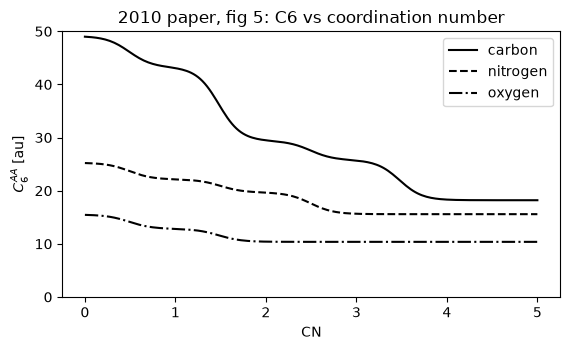

In [3]:
core = DFTD3()
table2 = {"He-He": (2, 2, 1.54), "Ne-Ne": (10, 10, 6.14), "Ar-Ar": (18, 18, 64.2), "Kr-Kr": (36, 36, 129.7),
          "Xe-Xe": (54, 54, 288.6), "Rn-Rn": (86, 86, 410.5)}
print(f"{'pair':8s} {'paper table II (TDDFT)':>24s} {'xnn reference table':>20s}")
for name, (zi, zj, val) in table2.items():
    print(f"{name:8s} {val:24.2f} {float(core.c6ref[0, 0, zi, zj]):20.2f}")
# carbon in ethane (CN ~4, ref 5), ethene (CN ~3, ref 4), ethyne (CN ~2, ref 3): table II gives 18.1 / 25.7 / 29.3
for label, ref_idx, val in [("C-C (sp3)", 4, 18.1), ("C-C (sp2)", 3, 25.7), ("C-C (sp)", 2, 29.3)]:
    print(f"{label:10s} paper {val:6.1f}   xnn {float(core.c6ref[ref_idx, ref_idx, 6, 6]):6.2f}  (reference CN {float(core.refcn[ref_idx, 6]):.4f})")

cn = torch.linspace(0.0, 5.0, 201)
fig, ax = plt.subplots(figsize=(5.8, 3.6))
for Z, name, style in [(6, "carbon", "-"), (7, "nitrogen", "--"), (8, "oxygen", "-.")]:
    z = torch.full((201,), Z, dtype=torch.long)
    w = core.reference_weights(z, cn)
    c6 = core.c6_matrix(z, w, core._species_vectors(z, w)).diagonal()
    ax.plot(cn.numpy(), c6.numpy(), "k", ls=style, label=name)
ax.set_xlabel("CN"); ax.set_ylabel(r"$C_6^{AA}$ [au]"); ax.set_ylim(0, 50); ax.legend(); ax.set_title("2010 paper, fig 5: C6 vs coordination number")
plt.tight_layout(); plt.show()


## Block 2: Two-body energies for the four damping functions · 2010 eq 4, 2011 eq 5

Energies, gradients and (for periodic systems) virials against `s-dftd3` for molecules
of increasing size, with the ATM term switched **on** ($s_9 = 1$) so that the
three-body block is exercised at the same time. The zero and modified-zero variants
use the tabulated pair cutoff radii $R_0^{AB}$ (sec II.D), BJ and optimized power the
$C_8/C_6$ radii of 2011 eq 7.


In [4]:
molecules = {"H2O": molecule("H2O"), "NH3": molecule("NH3"), "C6H6": molecule("C6H6"),
             "CH3CH2OH": molecule("CH3CH2OH"), "C60": molecule("C60")}
for variant in VARIANTS:
    report(molecules, variant)


--- BJ (rational) ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|
H2O                          3 -2.768882466396e-04    1.1e-19   1.7e-20        nan
NH3                          4 -5.886073790842e-04    4.3e-19   2.7e-20        nan
C6H6                        12 -9.349028322112e-03    3.5e-18   9.2e-19        nan
CH3CH2OH                     9 -3.458363342132e-03    4.3e-19   4.7e-20        nan


C60                         60 -1.647438695262e-01    8.3e-17   9.3e-18        nan
--- zero ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|
H2O                          3 -4.644341818395e-06    0.0e+00   1.7e-21        nan
NH3                          4 -2.108709186781e-05    1.7e-20   3.4e-20        nan
C6H6                        12 -3.102992576496e-03    4.3e-19   2.7e-19        nan
CH3CH2OH                     9 -1.867384951417e-03    8.7e-19   7.0e-19        nan
C60                         60 -6.769570637220e-02    2.8e-17   4.3e-18        nan
--- modified zero ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|
H2O                          3 -3.506926280896e-04    1.6e-19   2.4e-19        nan


NH3                          4 -9.826380693574e-04    1.3e-18   6.2e-19        nan
C6H6                        12 -2.242281655191e-02    3.5e-18   2.0e-18        nan
CH3CH2OH                     9 -5.737490760271e-03    1.7e-18   5.4e-19        nan
C60                         60 -3.349665585052e-01    5.6e-17   2.2e-17        nan
--- optimized power ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|
H2O                          3 -4.081700350218e-06    1.7e-21   3.4e-21        nan
NH3                          4 -1.667097267658e-05    6.8e-21   1.7e-20        nan
C6H6                        12 -4.940350244912e-03    0.0e+00   3.3e-19        nan
CH3CH2OH                     9 -1.323450154247e-03    2.2e-19   1.9e-19        nan


C60                         60 -1.172030560151e-01    1.4e-17   6.5e-18        nan


## Block 3: Three-body term and periodic systems · eqs 11–14

The ATM term with zero damping on the 4/3-scaled pair radii and exponent $\alpha_6 + 2$;
switching it off must give exactly the two-body energy in both codes. Crystals
exercise the lattice sums of both terms (the primitive rocksalt and diamond cells, a
sheared silicon cell, graphite and a small periodic water box).


In [5]:
c60 = molecule("C60")
for variant in ("BJ (rational)", "zero"):
    damping, param, opts = VARIANTS[variant]
    p_off = (RationalDampingParam if damping == "bj" else ZeroDampingParam)
    kw = dict(s6=1.0, s9=0.0, alp=14.0, **({"s8": 1.2177, "a1": 0.4145, "a2": 4.8593} if damping == "bj" else {"s8": 0.928, "rs6": 1.287, "rs8": 1.0}))
    e_two_ref = float(reference(c60, p_off(**kw))["energy"])
    mine = xnn_d3(c60, damping=damping, s9=1.0)
    print(f"C60 {variant:14s}: E2 s-dftd3 {e_two_ref:.12e}  xnn {float(mine['energy_2body']) / HARTREE:.12e}  |diff| {abs(float(mine['energy_2body']) / HARTREE - e_two_ref):.1e};  "
          f"E3 (xnn) = {float(mine['energy_3body']) / HARTREE:+.4e} Eh = {abs(float(mine['energy_3body']) / float(mine['energy_2body'])) * 100:.1f} % of |E2|")

from ase.lattice.hexagonal import Graphite
rng = np.random.default_rng(0)
box = Atoms(cell=[6.2] * 3, pbc=True)
for _ in range(3):
    w = molecule("H2O"); w.rotate(rng.uniform(0, 360), rng.normal(size=3)); w.translate(rng.uniform(0, 6.2, 3)); box += w
sheared = bulk("Si", "diamond", a=5.43); c = sheared.cell[:].copy(); c[1, 0] += 0.5; sheared.set_cell(c, scale_atoms=False)
crystals = {"NaCl rocksalt": bulk("NaCl", "rocksalt", a=5.64), "Si diamond": bulk("Si", "diamond", a=5.43),
            "Si sheared cell": sheared, "graphite": Graphite("C", latticeconstant={"a": 2.46, "c": 6.70}),
            "water box (9 atoms)": box}
for variant in ("BJ (rational)", "zero"):
    report(crystals, variant)


C60 BJ (rational) : E2 s-dftd3 -1.693070178143e-01  xnn -1.693070178143e-01  |diff| 8.3e-17;  E3 (xnn) = +4.5631e-03 Eh = 2.7 % of |E2|
C60 zero          : E2 s-dftd3 -7.225885466028e-02  xnn -7.225885466028e-02  |diff| 4.2e-17;  E3 (xnn) = +4.5631e-03 Eh = 6.3 % of |E2|
--- BJ (rational) ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|


NaCl rocksalt                2 -1.602844766437e-02    1.4e-17   1.9e-18    5.6e-16


Si diamond                   2 -2.370652536860e-02    1.6e-16   1.9e-18    6.6e-16


Si sheared cell              2 -2.292151017203e-02    1.4e-16   8.7e-17    8.6e-16


graphite                     4 -2.104076546597e-02    1.5e-16   2.1e-18    2.0e-15


...

NaCl rocksalt                2 -1.599866534278e-02    1.3e-16   7.4e-19    8.3e-16


Si diamond                   2 -1.093548871998e-02    2.2e-16   1.3e-18    5.8e-16


Si sheared cell              2 -1.084858974641e-02    6.8e-17   4.2e-17    3.1e-16


graphite                     4 -1.276917484344e-02    1.3e-16   1.6e-18    2.2e-15


water box (9 atoms)          9 -3.429606773670e-03    2.2e-18   1.1e-18    6.8e-17


## Block 4: Heavy elements, matching cutoffs, switching windows

The reference table in xnn is the reference code's, including the simple-dftd3 1.1.0 references
for Fr–Lr (Grimme's original 2010 tables end at Pu with fewer references; xnn keeps
them too as `references="2010"`, the PhysNet/BAMBOO default); UF₆ probes it. Both
codes accept shorter real-space cutoffs and agree with matching values. xnn's quintic
switching windows (`switch_width_pair`, `switch_width_triple`) are a deliberate
extension, off by default, that keeps energy and forces continuous under a finite
cutoff in MD.


--- BJ (rational) ---
system                       N             E [Eh]  |dE| [Eh]   |dgrad|  |dvirial|
UF6 (Z = 92)                 7 -4.181076237797e-03    8.7e-19   4.1e-20        nan
PbH4 dimer (Z = 82)         10 -6.511533839911e-03    4.3e-18   1.1e-19        nan

cutoffs 12/9/10 bohr: dftd3 -9.919164262520e-03   xnn -9.919164262520e-03   |diff| 1.7e-18 Eh


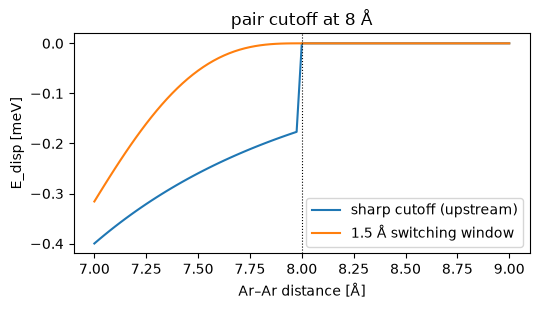

In [6]:
damping, param, opts = VARIANTS["BJ (rational)"]
uf6 = Atoms("UF6", positions=[[0, 0, 0], [2, 0, 0], [-2, 0, 0], [0, 2, 0], [0, -2, 0], [0, 0, 2], [0, 0, -2]])
pbh4 = Atoms("PbH4PbH4", positions=np.concatenate([molecule("SiH4").positions, molecule("SiH4").positions + [4.0, 0, 0]]))
report({"UF6 (Z = 92)": uf6, "PbH4 dimer (Z = 82)": pbh4}, "BJ (rational)")

cluster = molecule("CH3CH2OH") + molecule("CH3CH2OH"); cluster.positions[9:] += [4.0, 0.5, 0.3]
ref = reference(cluster, param, cutoffs=dict(disp2=12.0, disp3=9.0, cn=10.0))
mine = xnn_d3(cluster, damping="bj", s9=1.0, cutoff_pair=12 * BOHR, cutoff_triple=9 * BOHR, cutoff_cn=10 * BOHR)
print(f"\ncutoffs 12/9/10 bohr: dftd3 {float(ref['energy']):.12e}   xnn {mine['energy_au']:.12e}   |diff| {abs(mine['energy_au'] - float(ref['energy'])):.1e} Eh")

d = np.linspace(7.0, 9.0, 81)
sharp = D3Dispersion(cutoff_pair=8.0, cutoff_cn=8.0, cutoff_triple=8.0)
smooth = D3Dispersion(cutoff_pair=8.0, switch_width_pair=1.5, cutoff_cn=8.0, cutoff_triple=8.0)
E = {m: [float(xnn_d3(Atoms("Ar2", positions=[[0, 0, 0], [x, 0, 0]]), model=mod)["energy"]) * 1e3 for x in d]
     for m, mod in [("sharp cutoff (upstream)", sharp), ("1.5 Å switching window", smooth)]}
plt.figure(figsize=(5.5, 3.2))
for k, v in E.items(): plt.plot(d, v, label=k)
plt.axvline(8.0, color="k", ls=":", lw=0.8); plt.xlabel("Ar–Ar distance [Å]"); plt.ylabel("E_disp [meV]"); plt.legend(); plt.title("pair cutoff at 8 Å"); plt.tight_layout(); plt.show()


## Block 5: One implementation, every channel

The same `DFTD3` module serves the batched `AtomicGraph` path (training), the scripted
whole-system and pair-style ABIs (`TorchScriptPotential`, LAMMPS) and the ASE
calculator; and it wraps a short-range model without touching that model's own
neighborhood.


In [7]:
from xnn.common.config import from_dict
from xnn.common.data import build_neighbor_list
from xnn.common.deploy import TorchScriptPotential, XNNCalculator
from xnn.common.models import build_model

atoms = molecule("C6H6")
d3 = D3Dispersion(s9=1.0, cutoff_pair=12.0, cutoff_triple=9.0, cutoff_cn=10.0)
eager = xnn_d3(atoms, model=d3)
scripted = torch.jit.script(TorchScriptPotential(d3, d3.cutoff).eval())
ts = scripted(torch.tensor(atoms.positions), torch.tensor(atoms.numbers))
ei, cs = build_neighbor_list(torch.tensor(atoms.positions), d3.cutoff)
ts_pair = scripted.forward_lammps(torch.tensor(atoms.positions), ei, cs, torch.tensor(atoms.numbers), torch.zeros(3, 3))
atoms.calc = XNNCalculator(ForceStressOutput(d3), cutoff=d3.cutoff)
print(f"eager           {float(eager['energy']):.15f} eV")
print(f"TorchScript     {float(ts['energy']):.15f} eV   |dF| = {float((ts['forces'] - eager['forces']).abs().max()):.1e}")
print(f"pair-style ABI  {float(ts_pair['energy']):.15f} eV")
print(f"ASE calculator  {atoms.get_potential_energy():.15f} eV")

graphs = [structure_to_graph({"pos": molecule(n).positions, "atomic_numbers": molecule(n).numbers}, d3.cutoff) for n in ("H2O", "CH4", "C6H6")]
print("batch vs single |dE| =", float((d3(collate(graphs))["energy"] - torch.stack([d3(g)["energy"][0] for g in graphs])).abs().max()))

cfg = from_dict({"model": {"name": "mace", "cutoff": 4.5, "n_interactions": 1, "n_rbf": 6, "n_features": 8,
                           "extra": {"species": [1, 6], "l_max": 2,
                                     "dispersion": {"name": "d3", "s9": 1.0, "cutoff_pair": 12.0, "cutoff_triple": 9.0, "cutoff_cn": 10.0}}}})
torch.manual_seed(0)
wrapped = build_model(cfg.model)
out = wrapped(structure_to_graph({"pos": atoms.positions, "atomic_numbers": atoms.numbers}, wrapped.cutoff))
core_only = wrapped.model(structure_to_graph({"pos": atoms.positions, "atomic_numbers": atoms.numbers}, 4.5))
print(f"MACE+D3: cutoff {wrapped.cutoff} Å, E = E_sr + E_disp: {float(out['energy']):.6f} = {float(core_only['energy']):.6f} + {float(out['energy_disp']):.6f}  (|E_sr - MACE alone| = {abs(float(out['energy_sr']) - float(core_only['energy'])):.1e})")


eager           -0.254400020697171 eV
TorchScript     -0.254400020697171 eV   |dF| = 0.0e+00
pair-style ABI  -0.254400020697171 eV
ASE calculator  -0.254400020697171 eV
batch vs single |dE| = 0.0


MACE+D3: cutoff 12.0 Å, E = E_sr + E_disp: 6.322566 = 6.576966 + -0.254400  (|E_sr - MACE alone| = 0.0e+00)


## Summary

| block | quantity | xnn vs `s-dftd3` |
|---|---|---|
| 1 | reference C6 and CN interpolation | reproduces table II / fig 5 of the 2010 paper |
| 2 | two-body + ATM energies and gradients, four damping functions, up to C60 | ~1e-17 Eh, ~1e-17 Eh/bohr |
| 3 | periodic energies, gradients, virials (BJ and zero) | ~1e-17 |
| 4 | actinide references, matching shorter cutoffs | ~1e-17 Eh |
| 5 | eager / TorchScript / pair-style / ASE / batch | identical |
